# Semiclassical QFI in the driven 2-D atomic array — benchmark and convergence

Raw data produced by the runners in this folder (`sc_run_batches.py`,
`mcwf_run.py`); everything here is analysis only.  The sensed parameter is the
Rabi frequency $\Omega$ and both methods use the same generator
$\partial_\Omega H = -\sum_n \sigma^x_n$, so the semiclassical QFI
$\mathcal{I}_\omega^{\rm sc}$ and the Gammelmark–Mølmer monitored QFI
$\mathcal{I}_\omega^{\rm mon}$ are compared **directly** (both unnormalised).
Everything is plotted as the **rate per atom** $\mathcal{I}_\omega(t)/(N t)$:
the QFI grows linearly in $t$ once the transient is over, and $\propto N$ in
both methods, so this is the form in which the curves are comparable.

Three levels of comparison, set by what a reference costs at that lattice size:

| tier | $L$ | reference | status |
|------|-----|-----------|--------|
| 1 | 2, 3 | exact density-matrix hierarchy — no Monte-Carlo, no $\mathrm{d}t$ bias | benchmark |
| 2 | 4 | statevector MCWF, $N=16$ — Monte-Carlo, hence error bars | benchmark |
| 3 | 6, 8, 10 | none — the master equation is out of reach | exploratory |

The MCWF reference of tier 2 is itself validated at $L=2$, where the exact
answer is known: the last panel of the first figure is that check.

In [2]:
import sys, pathlib
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Repository-wide SciencePlots figure style (../plotstyle.py): REVTeX geometry,
# Computer Modern at 10 pt, outward ticks.
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from plotstyle import COLUMN_WIDTH, TEXT_WIDTH, figsize, limit_ticks, use_style

sys.path.insert(0, str(pathlib.Path.cwd()))
from atomarray import qfi_from_powersums   # same reduction as sc_aggregate.py

use_style()          # use_style(latex=False) → same look without a LaTeX install

# ── Data model ───────────────────────────────────────────────────────────────
# Every run — whichever method, whichever campaign — is loaded into one flat
# record: {method, L, N, Omega, factor, times, qfi, qfi_stderr, n_traj, path}.
# The two figures below are then just filters over that list, so a new run only
# has to land on disk to appear in them.
#
#   results_semiclassical/[omega_<Ω>/]dt_<factor>/   sc_L<L>_seed*.npz  (power-sum
#       slices, summed here exactly as sc_aggregate.py does) or the already
#       aggregated sc_array_L<L>.npz.  Slices win where both exist.
#   results_exact/[omega_<Ω>/]                       mcwf_L<L>.npz, method="exact"
#   results_mcwf/dt_<factor>/                        mcwf_L<L>.npz, method="mcwf"
#
# The Ω of a run and its dimensionless step Γ0 dt are read from the file itself,
# never from the folder name, so a mislabelled directory cannot shift a curve.

SC_ROOT   = Path("results_semiclassical")
REF_ROOTS = [Path("results_exact"), Path("results_mcwf")]


def _factor(d):
    """Dimensionless step: the runners use dt = factor / max(2Ω, Γ0)."""
    return float(d["dt"]) * max(2.0 * float(d["Omega"]), float(d["gamma0"]))


def _rec(d, **extra):
    return dict(L=int(d["L"]), N=int(d["N"]), Omega=float(d["Omega"]),
                gamma0=float(d["gamma0"]), T=float(d["T"]), dt=float(d["dt"]),
                factor=_factor(d), **extra)


def load_semiclassical(root=SC_ROOT):
    """One record per (directory, L): power-sum slices summed, else the aggregate."""
    slices = defaultdict(list)
    for f in sorted(root.glob("**/sc_L*_seed*.npz")):
        d = np.load(f)
        if "s1" in d.files:                       # a power-sum slice, not an aggregate
            slices[(f.parent, int(d["L"]))].append((f, d))

    recs = []
    for (parent, L), items in slices.items():
        items.sort(key=lambda fd: int(fd[1]["batch_start"]))
        ref = items[0][1]
        s = [sum(d[k] for _, d in items) for k in ("s1", "s2", "s3", "s4")]
        n = sum(int(d["count"]) for _, d in items)
        q, e = qfi_from_powersums(n, *s)          # QFI = 4·Var(X), 4th-moment error bar
        recs.append(_rec(ref, method="sc", times=np.asarray(ref["times"], float),
                         qfi=q, qfi_stderr=e, n_traj=n,
                         path=f"{parent}/sc_L{L} ({len(items)} slice(s))"))

    for f in sorted(root.glob("**/sc_array_L*.npz")):
        d = np.load(f)
        if (f.parent, int(d["L"])) in slices:     # identical by construction — skip
            continue
        recs.append(_rec(d, method="sc", times=np.asarray(d["times"], float),
                         qfi=d["qfi"], qfi_stderr=d["qfi_stderr"],
                         n_traj=int(d["n_traj"]), path=str(f)))
    return recs


def load_reference(roots=REF_ROOTS):
    """Exact (deterministic) and MCWF monitored-QFI runs, tagged by their method."""
    recs = []
    for root in roots:
        for f in sorted(root.glob("**/mcwf_L*.npz")):
            d = np.load(f)
            recs.append(_rec(d, method=str(d["method"]),
                             times=np.asarray(d["times"], float),
                             qfi=d["qfi"], qfi_stderr=d["qfi_stderr"],
                             n_traj=int(d["n_traj"]), path=str(f)))
    return recs


SC, REF = load_semiclassical(), load_reference()
ALL = SC + REF


def rate(r):
    """(t, ℐ_ω/(N t), err/(N t)) at t > 0 — the per-atom QFI rate everything uses.

    Per atom because both methods give ℐ_ω ∝ N to about a percent over L = 2…10,
    so one axis then carries every lattice size; per unit time because ℐ_ω itself
    grows linearly in t at long times.
    """
    t = r["times"]
    m = t > 0                                     # rate undefined at t = 0
    norm = t[m] # *r["N"] # uncomment if you want per-atom rates
    return t[m], r["qfi"][m] / norm, r["qfi_stderr"][m] / norm


def pick(recs, L, Omega, factor=None, method=None):
    """One run at this (L, Ω): the cheapest that is at least as fine as `factor`.

    Never trades a converged step for a coarser one just because the coarser one
    is nearer in ratio — where nothing that fine exists it falls back to the
    finest run present, and the caller reports which step it actually got.
    `factor=None` always takes the finest.
    """
    c = [r for r in recs if r["L"] == L and r["Omega"] == Omega
         and (method is None or r["method"] == method)]
    if not c:
        return None
    fine = [r for r in c if r["factor"] <= factor * 1.001] if factor else []
    return max(fine, key=lambda r: r["factor"]) if fine else min(c, key=lambda r: r["factor"])


def reference_for(L, Omega):
    """Exact if it exists (no MC/dt bias), else the finest-step MCWF, else None."""
    return (pick(REF, L, Omega, method="exact")
            or pick(REF, L, Omega, method="mcwf"))


# ── Inventory of everything on disk ──────────────────────────────────────────
print(f"{'method':>6} {'Ω/Γ0':>5} {'L':>3} {'N':>4} {'Γ0 dt':>7} {'n_traj':>7} "
      f"{'ℐ/(N T)':>9} {'rel.err':>8}  source")
for r in sorted(ALL, key=lambda r: (r["Omega"], r["L"], r["method"], -r["factor"])):
    _, _y, _e = rate(r)
    q, e = _y[-1], _e[-1]
    print(f"{r['method']:>6} {r['Omega']:>5g} {r['L']:>3d} {r['N']:>4d} {r['factor']:>7g} "
          f"{r['n_traj']:>7d} {q:>9.2f} {e / q if q else 0:>7.2%}  {r['path']}")
print("\nΩ/Γ0 campaigns present:", sorted({r['Omega'] for r in ALL}))

method  Ω/Γ0   L    N   Γ0 dt  n_traj   ℐ/(N T)  rel.err  source
 exact  0.25   2    4 0.150754       0     73.43   0.00%  results_exact/omega_025/mcwf_L2.npz
    sc  0.25   2    4   0.001   10000     42.51   1.38%  results_semiclassical/omega_025/dt_001/sc_L2 (1 slice(s))
 exact  0.25   3    9 0.150754       0    194.90   0.00%  results_exact/omega_025/mcwf_L3.npz
    sc  0.25   3    9   0.001   10000    111.37   1.41%  results_semiclassical/omega_025/dt_001/sc_L3 (1 slice(s))
    sc  0.25   5   25   0.001   10000    332.09   1.38%  results_semiclassical/omega_025/dt_001/sc_L5 (1 slice(s))
    sc  0.25  10  100   0.001   10000   1360.23   1.37%  results_semiclassical/omega_025/dt_001/sc_L10 (1 slice(s))
 exact   0.5   2    4 0.150754       0     67.84   0.00%  results_exact/omega_05/mcwf_L2.npz
    sc   0.5   2    4   0.001   10000     45.94   1.39%  results_semiclassical/omega_05/dt_001/sc_L2 (1 slice(s))
 exact   0.5   3    9 0.150754       0    166.98   0.00%  results_exact/omega_0

## 1. Semiclassical against exact

Panel (a) is the time trace at the strongest drive on disk,
$\Omega/\Gamma_0 = 4$: $L = 2$ and $L = 3$, the semiclassical curve solid and
its reference dashed (exact) or dash-dotted with a $\pm1\sigma$ band (MCWF) in
the same colour.  Panel (b) reads both methods at the one time marked by the
dotted line in (a), $\Gamma_0 t = $ `KT_CUT`, and plots them against the drive,
so each campaign $\Omega/\Gamma_0 = 1, 2, 4$ contributes one pair of points per
lattice size.  The two panels share the $y$ axis and the quantity on it, the
rate $\mathcal{I}_\omega(t)/t$, so a marker in (b) is the corresponding curve of
(a) sampled where the dotted line crosses it.

What it shows is that the truncated-Wigner error is set by the drive, not by the
lattice.  At $\Omega/\Gamma_0 = 1$ the semiclassical rate sits well below the
exact one — the mean-field factorisation is at its worst where the drive does
not dominate the collective decay — and the gap closes as $\Omega$ grows: from
$-17\%$ ($L = 2$) and $-14\%$ ($L = 3$) at $\Omega/\Gamma_0 = 1$ to a couple of
percent at $\Omega/\Gamma_0 = 4$, the drive of panel (a).  Both sizes trace the
same closing gap, so it is a per-atom error, not one that accumulates with $N$.
The printout below quotes the ratio behind every point of panel (b).

$L = 4$ has semiclassical runs at every $\Omega$ but no reference yet, so it is
left out of both panels; add it to `L_SHOW` once the MCWF runs land in
`results_mcwf/` and `reference_for()` picks them up on its own — as MCWF, drawn
dash-dotted with its band.

Ω/Γ0 = 4, L= 2: semiclassical at Γ0 dt = 0.001 (requested 0.001), n_traj = 10000
Ω/Γ0 = 4, L= 3: semiclassical at Γ0 dt = 0.001 (requested 0.001), n_traj = 10000
Ω/Γ0 = 4, L=10: semiclassical at Γ0 dt = 0.001 (requested 0.001), n_traj = 10000
panel (a): no reference yet at Ω/Γ0 = 4, L = 10


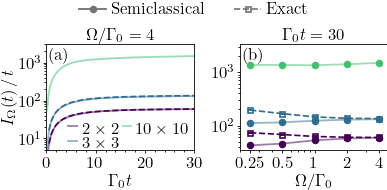


Γ0 t = 30 — semiclassical / reference (panel (b)):
  Ω/Γ0 = 0.25: L=2 0.579 (-42.1%, exact),  L=3 0.571 (-42.9%, exact)
               no reference yet for L = 10
  Ω/Γ0 = 0.5: L=2 0.677 (-32.3%, exact),  L=3 0.687 (-31.3%, exact)
               no reference yet for L = 10
  Ω/Γ0 = 1: L=2 0.846 (-15.4%, exact),  L=3 0.847 (-15.3%, exact)
               no reference yet for L = 10
  Ω/Γ0 = 2: L=2 0.950 (-5.0%, exact),  L=3 0.941 (-5.9%, exact)
               no reference yet for L = 10
  Ω/Γ0 = 4: L=2 0.992 (-0.8%, exact),  L=3 0.978 (-2.2%, exact)
               no reference yet for L = 10


In [3]:
# ═══ Figure knobs ════════════════════════════════════════════════════════════
# Two panels of the same quantity, the per-time QFI rate ℐ_Ω(t)/t:
#   (a) the full time trace at one drive — semiclassical against its reference,
#       one colour per lattice size, so the shape of the agreement is visible;
#   (b) that same rate read at Γ0 t = KT_CUT (the dotted line in (a)) as a
#       function of the drive, semiclassical against exact at every campaign on
#       disk, so the size of the agreement can be read off against Ω.
# The panels share the y axis: a marker in (b) is literally the corresponding
# curve of (a) sampled where the dotted line crosses it.
OMEGA_A   = 4.0        # drive shown in panel (a)
L_SHOW    = [2, 3, 10]     # lattice sizes in both panels; one that is missing at
                       # some Ω is simply left out there
OMEGAS    = None       # x values of panel (b); None → every Ω/Γ0 campaign on
                       # disk, ascending, so a new campaign adds a point by itself
DT_FACTOR = 0.001      # as in figure 2: cheapest semiclassical run at least this fine
KT_CUT    = 30.0       # Γ0 t at which panel (b) reads both curves
SAVEPATH  = Path("qfi_omega_scan_array.pdf")       # None → don't write a file

# The reference of a given (L, Ω) is whatever exists for it — exact where the
# master equation is affordable, MCWF where it is not, nothing at all until
# then.  reference_for() makes that choice and the line/marker style says which
# one was made, so new runs need only land on disk to appear here.
SHAREY    = False       # (b) on the axis of (a): a marker is then literally
                       # a curve of (a) sampled at the dotted line.  False
                       # lets (b) zoom on the gap instead, at YLIM_B
YLIM      = (0, 175)   # panel (a), and (b) too while SHAREY; None → autoscale.
                       # The top is headroom: it clears the (b) tag off the
                       # highest point, the exact L = 3 one at Ω/Γ0 = 1
YLIM_B    = None       # panel (b) when not sharing; None → autoscale
XLIM_A    = (0, 30)    # Γ0 t window of panel (a)
XPAD_B    = 0.1       # x margin of panel (b), in units of Ω/Γ0
CMAP_L    = plt.cm.viridis
CMAP_SPAN = (0.0, 0.7)
LW        = 1.1
REF_LS    = {"exact": "--", "mcwf": "-."}          # reference line style by method
SC_MK, REF_MK = "o", {"exact": "s", "mcwf": "^"}   # panel (b) markers
MS_SC, MS_REF = 3.5, 3.0         # marker sizes, as in the BTC comparison figure
ELW, CAPSIZE  = 0.8, 1.5         # error-bar width and cap size, likewise
GUIDE_ALPHA   = 0.5              # the semiclassical points are the measurement, so
                                 # the line through them is only a faint guide,
                                 # drawn separately from the error bars
MARK_CUT  = True       # draw the read-out time of panel (b) into panel (a)
FIGWIDTH  = TEXT_WIDTH * 0.5           # a figure* row; shrink for a narrower cut
FIGRATIO  = 1.0                  # per-panel aspect (see plotstyle.figsize)
TAGS      = "ab"                 # panel tags, assigned in reading order
TAG_XY    = [(0.02, 0.98),       # one corner per panel: (a) rises to the right,
             (0.02, 0.98)]       # (b) is highest on the left, so they tag opposite
                                 # corners.  x > 0.5 flips the alignment by itself
CORNER    = (0.97, 0.0)         # the rate plateaus, so the lower-right corner
                                 # of panel (a) is the free one for the L key
SUPKEY_H  = 0.06                 # figure-height fraction reserved above the panels
                                 # for the line-style key, in place of a suptitle
N_XTICKS, N_YTICKS = 4, 5        # tick-label budgets
XLABEL_A  = r"$\Gamma_0 t$"
XLABEL_B  = r"$\Omega/\Gamma_0$"
YLABEL    = r"$I_{\Omega} (t)\,/\, t$"

omegas = sorted({r["Omega"] for r in SC}) if OMEGAS is None else list(OMEGAS)
color_of_L = {L: c for L, c in
              zip(L_SHOW, CMAP_L(np.linspace(*CMAP_SPAN, len(L_SHOW))))}


def at_cut(r, t_cut=None):
    """(ℐ_ω/t, its error) of one run at Γ0 t = `t_cut`; None if it ends earlier."""
    t, y, e = rate(r)
    t_cut = KT_CUT if t_cut is None else t_cut
    if t_cut > t[-1] * 1.001:
        return None
    return np.interp(t_cut, t, y), np.interp(t_cut, t, e)


fig, axes = plt.subplots(1, 2, sharey=SHAREY,
                         figsize=figsize(FIGWIDTH, ratio=FIGRATIO, cols=2, rows=1))
ax_a, ax_b = axes

# ── (a) example curves at one drive ──────────────────────────────────────────
methods_drawn = set()                              # which reference kinds are drawn
L_handles = {}                                     # L → line, for the shared key
sc_a = [r for r in SC if r["Omega"] == OMEGA_A]
for L in L_SHOW:
    r = pick(sc_a, L, OMEGA_A, DT_FACTOR)
    if r is None:
        print(f"panel (a): no semiclassical run at Ω/Γ0 = {OMEGA_A:g}, L = {L}")
        continue
    c = color_of_L[L]
    t, y, e = rate(r)
    L_handles.setdefault(L, ax_a.plot(t, y, color=c, lw=LW, zorder=3, alpha=0.5,
                                      label=rf"${L} \times {L}$")[0])
    if e.any():
        ax_a.fill_between(t, y - e, y + e, color=c, alpha=0.20, lw=0, zorder=2)
    print(f"Ω/Γ0 = {OMEGA_A:g}, L={L:2d}: semiclassical at Γ0 dt = {r['factor']:g} "
          f"(requested {DT_FACTOR:g}), n_traj = {r['n_traj']}")

    rr = reference_for(L, OMEGA_A)
    if rr is None:
        print(f"panel (a): no reference yet at Ω/Γ0 = {OMEGA_A:g}, L = {L}")
        continue
    methods_drawn.add(rr["method"])
    tr, yr, er = rate(rr)
    ax_a.plot(tr, yr, color=c, ls=REF_LS[rr["method"]], lw=1.0, zorder=4)
    if er.any():
        ax_a.fill_between(tr, yr - er, yr + er, color=c, alpha=0.30, lw=0, zorder=2)

if MARK_CUT:                                       # where panel (b) reads the curves
    ax_a.axvline(KT_CUT, color="0.6", ls=":", lw=0.7, zorder=1)

ax_a.set_title(rf"$\Omega/\Gamma_0 = {OMEGA_A:g}$", fontsize=10, pad=3)
ax_a.set_xlabel(XLABEL_A)
ax_a.set_xlim(*XLIM_A)
ax_a.set_ylim(5,3000)
ax_a.set_yscale('log')
ax_a.set_ylabel(YLABEL)
ax_a.set_xticks([0, 10, 20, 30])
ax_a.tick_params(axis="y", pad=0.5)     

# ── (b) the same rate at Γ0 t = KT_CUT, against the drive ────────────────────
benchmarked = []                                   # (Ω, L, sc/ref at the cut, method)
pending = defaultdict(list)                        # Ω → [L drawn without a reference]
for L in L_SHOW:
    c = color_of_L[L]
    xs, ys, es = [], [], []
    ref_x = defaultdict(list)                      # method → x, y, err (styles differ)
    ref_y, ref_e = defaultdict(list), defaultdict(list)
    for Omega in omegas:
        r = pick(SC, L, Omega, DT_FACTOR)
        v = at_cut(r) if r is not None else None
        if v is None:
            continue
        xs.append(Omega), ys.append(v[0]), es.append(v[1])

        rr = reference_for(L, Omega)
        vr = at_cut(rr) if rr is not None else None
        if vr is None:                             # no reference, or it ends too early
            pending[Omega].append(L)
            continue
        m = rr["method"]
        methods_drawn.add(m)
        ref_x[m].append(Omega), ref_y[m].append(vr[0]), ref_e[m].append(vr[1])
        benchmarked.append((Omega, L, v[0] / vr[0], m))

    if xs:
        ax_b.plot(xs, ys, color=c, ls="-", lw=LW, alpha=GUIDE_ALPHA, zorder=2)
        ax_b.errorbar(xs, ys, yerr=es, fmt=SC_MK, ms=MS_SC, lw=0, elinewidth=ELW,
                      capsize=CAPSIZE, color=c, zorder=4)
    for m in ref_x:
        ax_b.errorbar(ref_x[m], ref_y[m], yerr=ref_e[m], fmt=REF_MK[m] + REF_LS[m],
                      ms=MS_REF, lw=1.0, elinewidth=ELW, capsize=CAPSIZE,
                      color=c, mfc="none", zorder=3)

ax_b.set_title(rf"$\Gamma_0 t = {KT_CUT:g}$", fontsize=10, pad=3)
ax_b.set_xlabel(XLABEL_B)
#ax_b.set_xticklabels([f"{o:g}" for o in omegas])
#ax_b.xaxis.set_minor_locator(plt.NullLocator())    # the campaigns are the only x
ax_b.set_xscale('log')
ax_b.set_xlim(0.2,4.8)
ax_b.set_xticks([0.25, 0.5, 1, 2, 4])
ax_b.set_xticklabels([0.25, 0.5, 1, 2, 4])
ax_b.set_yscale('log')
ax_b.set_ylim(35,3300)
ax_b.tick_params(axis="y", pad=0.5) 
#ax_b.set_yticks([50, 100, 200, 400, 800])
#ax_b.set_yticklabels([f"{y:g}" for y in ax_b.get_yticks()])


for ax, tag, xy in zip(axes, TAGS, TAG_XY):
    ax.text(*xy, f"({tag})", transform=ax.transAxes, va="top",
            ha="right" if xy[0] > 0.5 else "left")

# The L colours are one key for the whole row — the same set is drawn in both
# panels — in the free corner of panel (a).
ax_a.legend(handles=list(L_handles.values()), loc="lower right", ncol=2,
            columnspacing=0.25, bbox_to_anchor=(*CORNER, 0, 0), frameon=False,
            handlelength=.5, fontsize=10, labelspacing=0., borderpad=0,
            borderaxespad=0)

# The line styles say which method a curve is, which is a statement about the
# whole figure, so they sit above it as a strip in place of a suptitle rather
# than inside one panel.  Only the reference kinds actually drawn are listed:
# the MCWF entry appears of itself with the first MCWF run.
style_handles = [plt.Line2D([], [], color="0.45", ls="-", lw=LW, marker=SC_MK,
                            ms=MS_SC, label="Semiclassical")]
style_handles += [plt.Line2D([], [], color="0.45", ls=REF_LS[m], lw=1.0,
                             marker=REF_MK[m], ms=MS_REF, mfc="none", label=lbl)
                  for m, lbl in (("exact", "Exact"), ("mcwf", "MCWF"))
                  if m in methods_drawn]
fig.legend(handles=style_handles, loc="upper center", ncol=len(style_handles),
           frameon=False, handlelength=1.6, columnspacing=1.8, fontsize=10,
           borderpad=0, borderaxespad=0.2)

fig.tight_layout(w_pad=0.6, rect=(0, 0, 1, 1 - SUPKEY_H))   # room for the key strip
if SAVEPATH:
    fig.savefig(SAVEPATH)
plt.show()

print(f"\nΓ0 t = {KT_CUT:g} — semiclassical / reference (panel (b)):")
for Omega in omegas:
    rows = [b for b in benchmarked if b[0] == Omega]
    if not rows:
        print(f"  Ω/Γ0 = {Omega:g}: no reference yet at any L shown")
        continue
    print(f"  Ω/Γ0 = {Omega:g}: " + ",  ".join(
        f"L={L} {ratio_:.3f} ({100 * (ratio_ - 1):+.1f}%, {meth})"
        for _, L, ratio_, meth in rows))
    if pending[Omega]:
        print(f"{'':15s}no reference yet for L = "
              + ", ".join(str(L) for L in pending[Omega]))
missing = [(Omega, L) for Omega in omegas for L in L_SHOW
           if pick(SC, L, Omega, DT_FACTOR) is None]
if missing:
    print("  no semiclassical run yet for (Ω, L) =", missing)

[11, 13]
[7]


/tmp/ipykernel_1300006/2901853348.py:5: RuntimeWarning: invalid value encountered in divide
  plt.plot(REF[MCWF_indices[0]]["times"], REF[MCWF_indices[0]]["qfi"]/REF[MCWF_indices[0]]["times"], label="MCWF L=3, dt="+str(REF[MCWF_indices[0]]["dt"]))
/tmp/ipykernel_1300006/2901853348.py:6: RuntimeWarning: invalid value encountered in divide
  plt.plot(REF[MCWF_indices[1]]["times"], REF[MCWF_indices[1]]["qfi"]/REF[MCWF_indices[1]]["times"], label="MCWF L=3, dt="+str(REF[MCWF_indices[1]]["dt"]))
/tmp/ipykernel_1300006/2901853348.py:7: RuntimeWarning: invalid value encountered in divide
  plt.plot(REF[EXACT_indices[0]]["times"], REF[EXACT_indices[0]]["qfi"]/REF[EXACT_indices[0]]["times"], label="Exact L=3")


(0.0, 30.0)

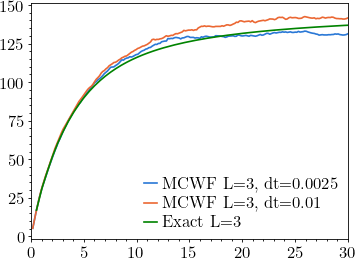

In [4]:
MCWF_indices = [i for i, r in enumerate(REF) if (r["method"] == "mcwf") & (r["L"] == 3)]
EXACT_indices = [i for i, r in enumerate(REF) if (r["method"] == "exact") & (r["L"] == 3) & (r["Omega"] == 2)]
print(MCWF_indices)
print(EXACT_indices)
plt.plot(REF[MCWF_indices[0]]["times"], REF[MCWF_indices[0]]["qfi"]/REF[MCWF_indices[0]]["times"], label="MCWF L=3, dt="+str(REF[MCWF_indices[0]]["dt"]))
plt.plot(REF[MCWF_indices[1]]["times"], REF[MCWF_indices[1]]["qfi"]/REF[MCWF_indices[1]]["times"], label="MCWF L=3, dt="+str(REF[MCWF_indices[1]]["dt"]))
plt.plot(REF[EXACT_indices[0]]["times"], REF[EXACT_indices[0]]["qfi"]/REF[EXACT_indices[0]]["times"], label="Exact L=3")
plt.legend()
plt.xlim(0,30)

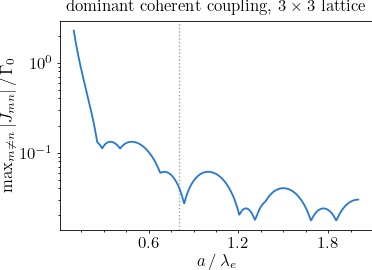

In [5]:
# ── Dominant coherent coupling vs lattice constant ───────────────────────────
# rate_matrices() (atomarray/geometry.py) returns the coherent dipole-dipole
# matrix J_mn from the free-space Green's tensor; its diagonal is zero and it
# is otherwise largest between nearest neighbours, so max_{m != n} |J_mn| is
# the dominant entry.  Scanned over the lattice spacing a (units of lambda_e),
# same convention (EP_CIRCULAR_XY, Gamma0 = 1) as the runners in this folder.
# Log y axis: J_mn falls off across orders of magnitude as a grows, from the
# near-field divergence at small a to the oscillatory far-field tail. The
# dotted line marks a = 0.8, the lattice spacing the runs on disk actually use.
from atomarray import square_lattice, rate_matrices, EP_CIRCULAR_XY

L_J = 3                                    # lattice side for the scan; the
                                           # dominant (nearest-neighbour) entry
                                           # barely depends on L
A_MIN, A_MAX, N_A = 0.1, 2.0, 400
A_RUN = 0.8                                # lattice spacing used by sc_run_batches.py / mcwf_run.py
a_vals = np.linspace(A_MIN, A_MAX, N_A)

J_dom = np.empty_like(a_vals)
for i, a in enumerate(a_vals):
    pos = square_lattice(L_J, a)
    _, J = rate_matrices(pos, EP_CIRCULAR_XY, Gamma0=1.0)
    J_dom[i] = np.abs(J).max()

fig, ax = plt.subplots(figsize=figsize(COLUMN_WIDTH, ratio=0.75))
ax.plot(a_vals, J_dom, lw=1.1, color="C0")
ax.axvline(A_RUN, color="0.6", ls=":", lw=0.8, zorder=1)
ax.set_xlabel(r"$a\,/\,\lambda_e$")
ax.set_ylabel(r"$\max_{m\neq n}|J_{mn}|\,/\,\Gamma_0$")
ax.set_yscale("log")
ax.set_title(rf"dominant coherent coupling, ${L_J}\times{L_J}$ lattice")
limit_ticks(ax, 5, axis="x")
fig.tight_layout()
plt.show()


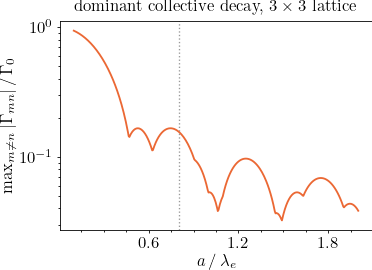

In [6]:
# ── Dominant collective-decay coupling vs lattice constant ──────────────────
# Same scan as above for the dissipative matrix Gamma_mn (rate_matrices' first
# return value): Gamma_nn = Gamma0 on the diagonal, so the dominant *coupling*
# is the largest off-diagonal entry, max_{m != n} |Gamma_mn| — the collective-
# decay analogue of the coherent J_mn plotted above.
A_MIN_G, A_MAX_G, N_A_G = 0.1, 2.0, 400
a_vals_G = np.linspace(A_MIN_G, A_MAX_G, N_A_G)

Gamma_dom = np.empty_like(a_vals_G)
for i, a in enumerate(a_vals_G):
    pos = square_lattice(L_J, a)
    Gamma, _ = rate_matrices(pos, EP_CIRCULAR_XY, Gamma0=1.0)
    off_diag = Gamma - np.diag(np.diag(Gamma))
    Gamma_dom[i] = np.abs(off_diag).max()

fig, ax = plt.subplots(figsize=figsize(COLUMN_WIDTH, ratio=0.75))
ax.plot(a_vals_G, Gamma_dom, lw=1.1, color="C1")
ax.axvline(A_RUN, color="0.6", ls=":", lw=0.8, zorder=1)
ax.set_xlabel(r"$a\,/\,\lambda_e$")
ax.set_ylabel(r"$\max_{m\neq n}|\Gamma_{mn}|\,/\,\Gamma_0$")
ax.set_yscale("log")
ax.set_title(rf"dominant collective decay, ${L_J}\times{L_J}$ lattice")
limit_ticks(ax, 5, axis="x")
fig.tight_layout()
plt.show()
